In [48]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

warnings.filterwarnings('ignore')

In [49]:
# Set seed for reproducibility
np.random.seed(42)

# Create dataset with mixed types
n = 1000

data = {
    'customer_id': range(1, n+1),
    'age': np.random.randint(18, 70, n),
    'gender': np.random.choice(['Male', 'Female'], n),
    'income': np.random.randint(30000, 150000, n),
    'subscription_type': np.random.choice(['Basic', 'Standard', 'Premium'], n, p=[0.5, 0.3, 0.2]),
    'contract_length': np.random.choice(['Monthly', 'Quarterly', 'Yearly'], n, p=[0.6, 0.25, 0.15]),
    'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer', 'Cash'], n),
    'monthly_usage_hours': np.random.randint(1, 100, n),
    'customer_service_calls': np.random.randint(0, 10, n),
    'has_loyalty_card': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'churned': np.random.choice(['Yes', 'No'], n, p=[0.2, 0.8])  # Target variable
}

df = pd.DataFrame(data)
df.to_csv('customer_churn_dataset.csv', index=False)

In [50]:
df.head()

,customer_id,age,gender,income,subscription_type,contract_length,payment_method,monthly_usage_hours,customer_service_calls,has_loyalty_card,region,churned
0,1,56,Male,75648,Basic,Yearly,Bank Transfer,45,9,No,South,No
1,2,69,Male,133537,Basic,Monthly,Cash,43,0,Yes,North,No
2,3,46,Male,39516,Basic,Quarterly,Credit Card,13,3,No,West,No
3,4,32,Female,142863,Basic,Monthly,Credit Card,13,6,No,South,Yes
4,5,60,Male,145005,Premium,Quarterly,Bank Transfer,60,8,No,West,No


# EDA

In [51]:
df.shape

(1000, 12)

In [52]:
df.columns

Index(['customer_id', 'age', 'gender', 'income', 'subscription_type',
       'contract_length', 'payment_method', 'monthly_usage_hours',
       'customer_service_calls', 'has_loyalty_card', 'region', 'churned'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             1000 non-null   int64 
 1   age                     1000 non-null   int32 
 2   gender                  1000 non-null   object
 3   income                  1000 non-null   int32 
 4   subscription_type       1000 non-null   object
 5   contract_length         1000 non-null   object
 6   payment_method          1000 non-null   object
 7   monthly_usage_hours     1000 non-null   int32 
 8   customer_service_calls  1000 non-null   int32 
 9   has_loyalty_card        1000 non-null   object
 10  region                  1000 non-null   object
 11  churned                 1000 non-null   object
dtypes: int32(4), int64(1), object(7)
memory usage: 78.3+ KB


In [54]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
income                    0
subscription_type         0
contract_length           0
payment_method            0
monthly_usage_hours       0
customer_service_calls    0
has_loyalty_card          0
region                    0
churned                   0
dtype: int64

In [55]:
df.dtypes

customer_id                int64
age                        int32
gender                    object
income                     int32
subscription_type         object
contract_length           object
payment_method            object
monthly_usage_hours        int32
customer_service_calls     int32
has_loyalty_card          object
region                    object
churned                   object
dtype: object

In [56]:
df.describe()

,customer_id,age,income,monthly_usage_hours,customer_service_calls
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,90630.119000,50.576000,4.562000
std,288.819436,14.99103,34673.181544,28.487291,2.901133
min,1.000000,18.00000,30207.000000,1.000000,0.000000
25%,250.750000,31.00000,60072.000000,25.750000,2.000000
50%,500.500000,44.00000,91615.500000,51.000000,5.000000
75%,750.250000,56.00000,121259.250000,76.000000,7.000000
max,1000.000000,69.00000,149979.000000,99.000000,9.000000


In [57]:
df['age'].max()

69

In [58]:
df['age'].min()

18

In [59]:
# Ages are right no anomility available. 

In [60]:
df['has_loyalty_card'].value_counts()

has_loyalty_card
No     689
Yes    311
Name: count, dtype: int64

In [61]:
df['payment_method'].value_counts()

payment_method
Cash             268
Bank Transfer    255
PayPal           248
Credit Card      229
Name: count, dtype: int64

In [62]:
df['subscription_type'].value_counts()

subscription_type
Basic       505
Standard    306
Premium     189
Name: count, dtype: int64

In [63]:
df['contract_length'].value_counts()

contract_length
Monthly      597
Quarterly    264
Yearly       139
Name: count, dtype: int64

In [65]:
df['gender'].value_counts()

gender
Male      524
Female    476
Name: count, dtype: int64

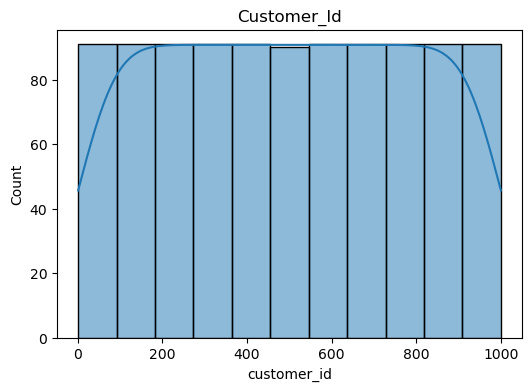

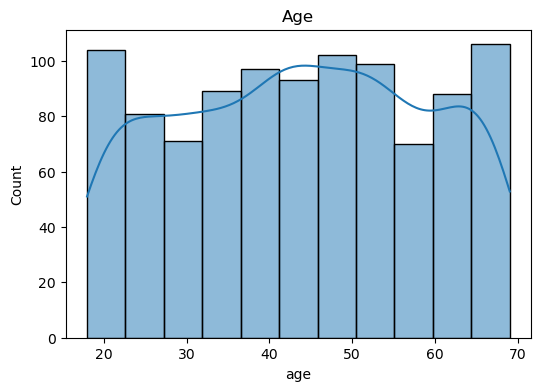

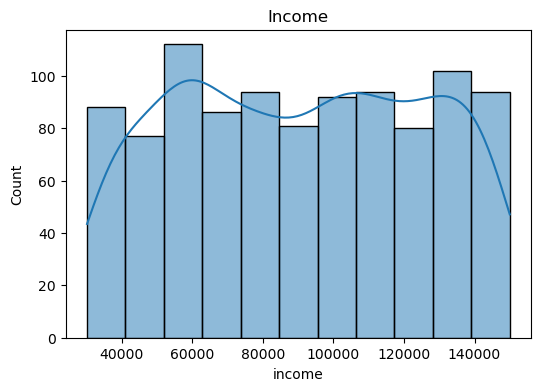

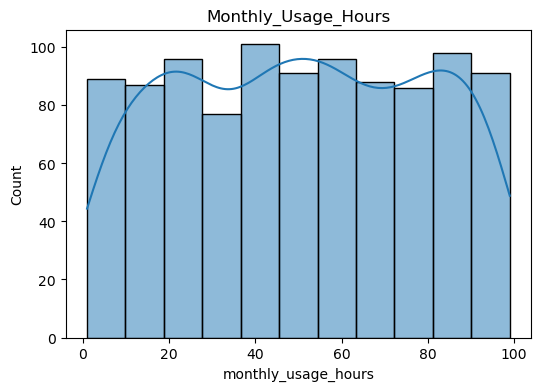

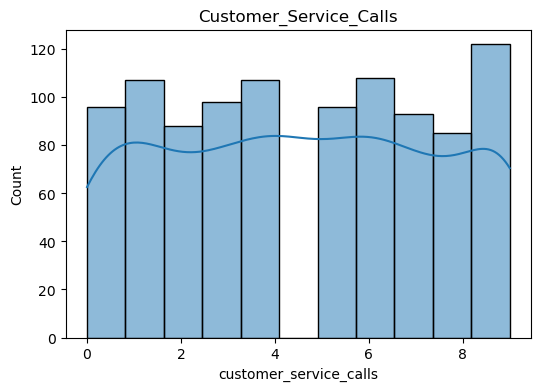

In [72]:
numeric_cols = df.select_dtypes(include='number') 

for col in numeric_cols: 
    plt.figure(figsize=(6,4))
    sns.histplot(df[col] , kde=True)
    plt.title(col.title())

In [73]:
df.head()

,customer_id,age,gender,income,subscription_type,contract_length,payment_method,monthly_usage_hours,customer_service_calls,has_loyalty_card,region,churned
0,1,56,Male,75648,Basic,Yearly,Bank Transfer,45,9,No,South,No
1,2,69,Male,133537,Basic,Monthly,Cash,43,0,Yes,North,No
2,3,46,Male,39516,Basic,Quarterly,Credit Card,13,3,No,West,No
3,4,32,Female,142863,Basic,Monthly,Credit Card,13,6,No,South,Yes
4,5,60,Male,145005,Premium,Quarterly,Bank Transfer,60,8,No,West,No


<Axes: xlabel='churned', ylabel='count'>

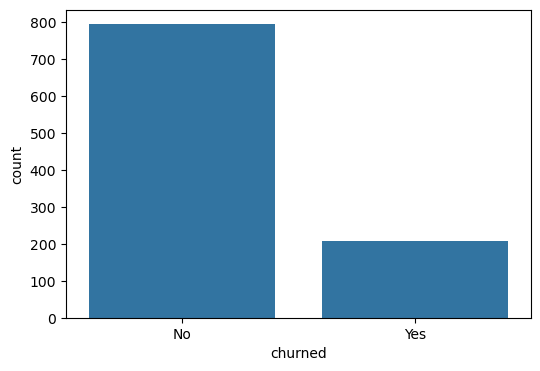

In [77]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['churned'])

<Axes: xlabel='gender', ylabel='count'>

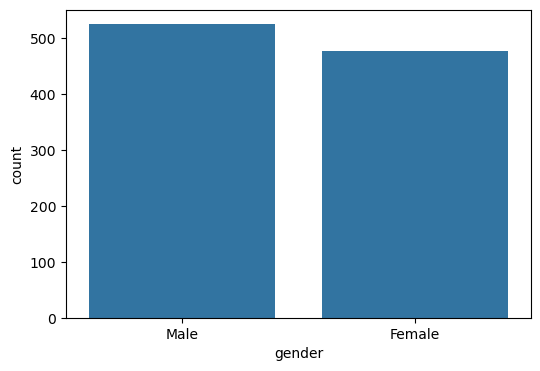

In [100]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['gender'])

<Axes: xlabel='subscription_type', ylabel='count'>

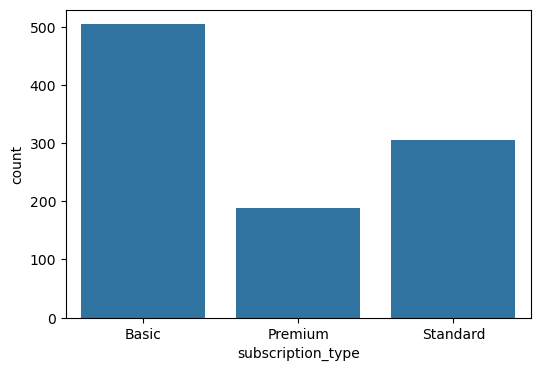

In [101]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['subscription_type'])

<Axes: xlabel='contract_length', ylabel='count'>

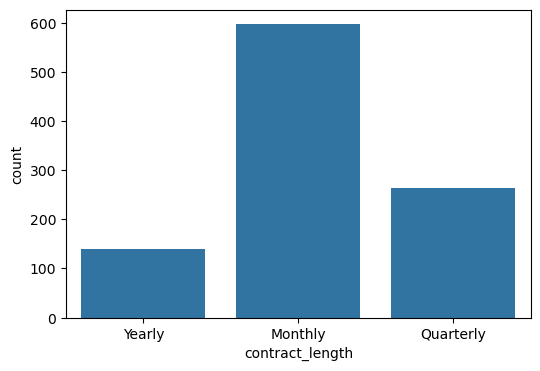

In [102]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['contract_length'])

<Axes: xlabel='has_loyalty_card', ylabel='count'>

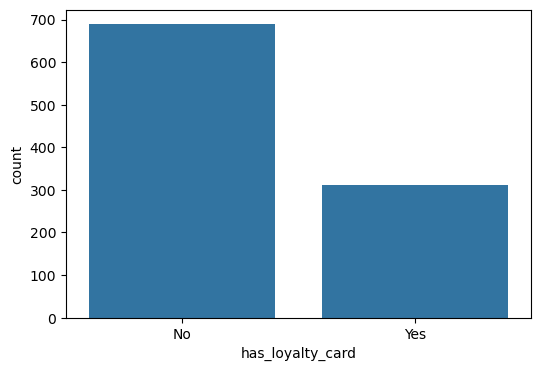

In [104]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['has_loyalty_card'])

<Axes: xlabel='region', ylabel='count'>

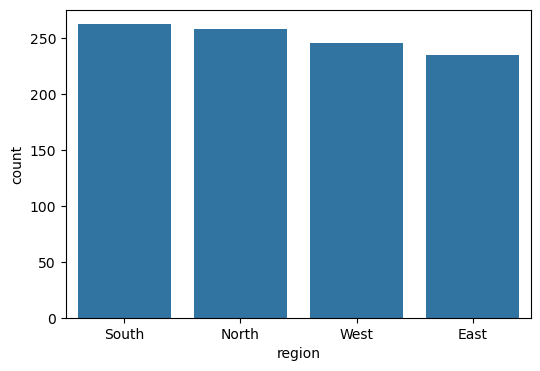

In [105]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['region'])

<Axes: xlabel='churned', ylabel='count'>

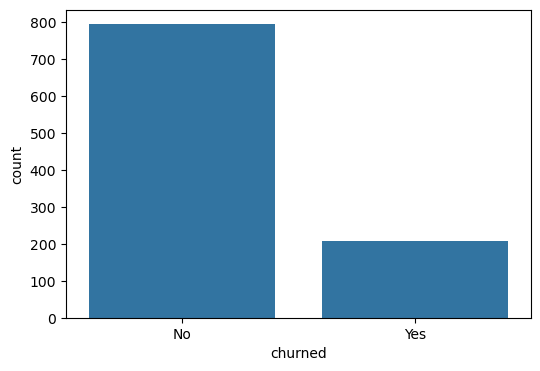

In [106]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['churned'])

<Axes: xlabel='payment_method', ylabel='count'>

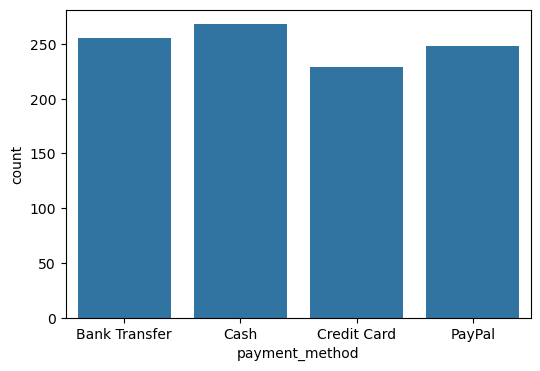

In [107]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['payment_method'])

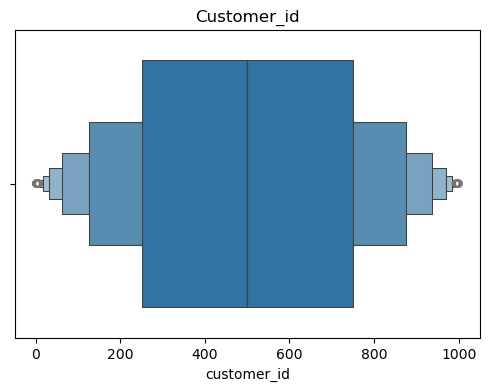

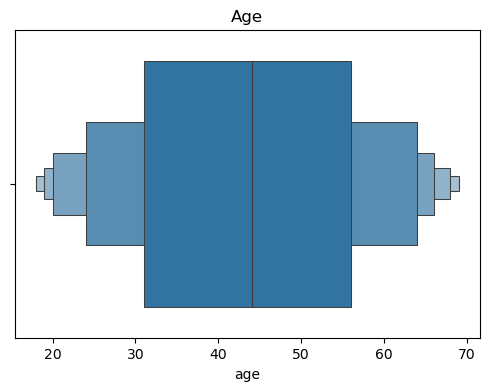

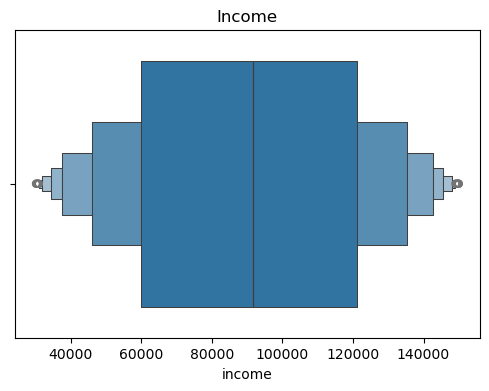

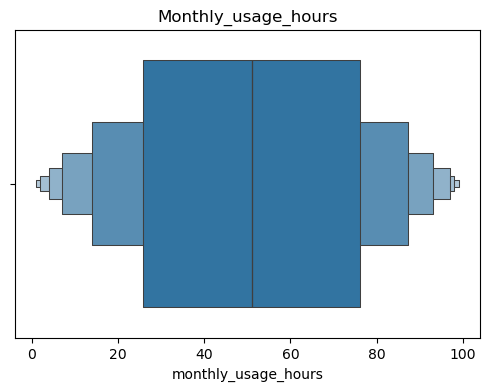

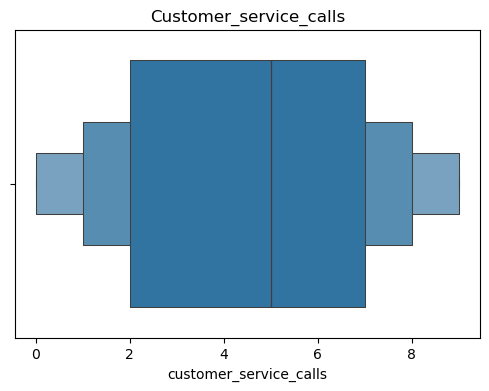

In [108]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxenplot(x=df[col])
    plt.title(col.capitalize())

<Axes: >

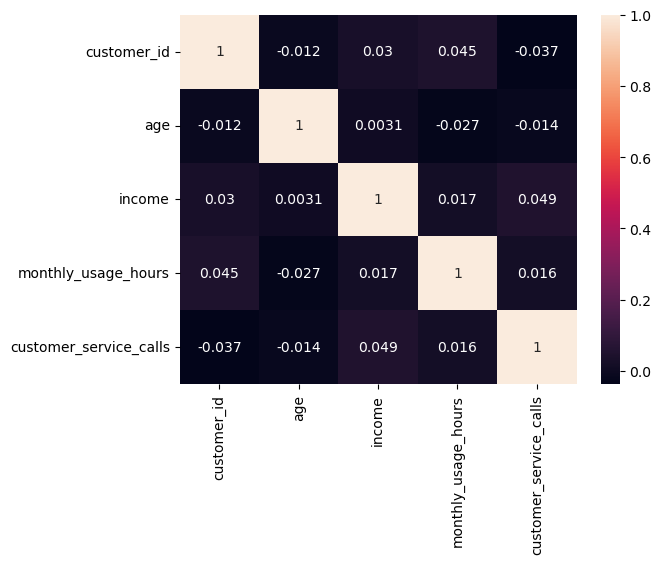

In [109]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [110]:
# Check correlations with target
numerical_cols = ['age', 'income', 'monthly_usage_hours', 'customer_service_calls']
for col in numerical_cols:
    # Convert churned to numeric (Yes=1, No=0)
    corr = df[col].corr(df['churned'].map({'Yes': 1, 'No': 0}))
    print(f"{col} vs churned: {corr:.3f}")

age vs churned: -0.038
income vs churned: -0.050
monthly_usage_hours vs churned: 0.060
customer_service_calls vs churned: 0.007


# Data Cleaning And Preprocessing

In [111]:
df_encode = df.copy()
df_encode.head()

,customer_id,age,gender,income,subscription_type,contract_length,payment_method,monthly_usage_hours,customer_service_calls,has_loyalty_card,region,churned
0,1,56,Male,75648,Basic,Yearly,Bank Transfer,45,9,No,South,No
1,2,69,Male,133537,Basic,Monthly,Cash,43,0,Yes,North,No
2,3,46,Male,39516,Basic,Quarterly,Credit Card,13,3,No,West,No
3,4,32,Female,142863,Basic,Monthly,Credit Card,13,6,No,South,Yes
4,5,60,Male,145005,Premium,Quarterly,Bank Transfer,60,8,No,West,No


In [118]:
df_encode.shape

(1000, 12)

In [120]:
df_encode.dropna(inplace=True)

In [121]:
df.shape

(1000, 12)

In [122]:
df_encode.isnull().sum()

customer_id               0
age                       0
gender                    0
income                    0
subscription_type         0
contract_length           0
payment_method            0
monthly_usage_hours       0
customer_service_calls    0
has_loyalty_card          0
region                    0
churned                   0
dtype: int64

In [123]:
df_encode.head()

,customer_id,age,gender,income,subscription_type,contract_length,payment_method,monthly_usage_hours,customer_service_calls,has_loyalty_card,region,churned
0,1,56,Male,75648,Basic,Yearly,Bank Transfer,45,9,No,South,No
1,2,69,Male,133537,Basic,Monthly,Cash,43,0,Yes,North,No
2,3,46,Male,39516,Basic,Quarterly,Credit Card,13,3,No,West,No
3,4,32,Female,142863,Basic,Monthly,Credit Card,13,6,No,South,Yes
4,5,60,Male,145005,Premium,Quarterly,Bank Transfer,60,8,No,West,No


In [124]:
df_encode['gender'].value_counts()

gender
Male      524
Female    476
Name: count, dtype: int64

In [127]:
df_encode['gender'] = df_encode['gender'].map({ "Male": 1, "Female": 0 })

In [129]:
df_encode['has_loyalty_card'].value_counts()

has_loyalty_card
No     689
Yes    311
Name: count, dtype: int64

In [132]:
df_encode['has_loyalty_card'] = df['has_loyalty_card'].map({ "Yes": 1, "No": 0 })

In [134]:
df_encode.rename(columns={ 'gender': 'is_male' }, inplace=True)

In [135]:
df_encode.head()

,customer_id,age,is_male,income,subscription_type,contract_length,payment_method,monthly_usage_hours,customer_service_calls,has_loyalty_card,region,churned
0,1,56,1,75648,Basic,Yearly,Bank Transfer,45,9,0,South,No
1,2,69,1,133537,Basic,Monthly,Cash,43,0,1,North,No
2,3,46,1,39516,Basic,Quarterly,Credit Card,13,3,0,West,No
3,4,32,0,142863,Basic,Monthly,Credit Card,13,6,0,South,Yes
4,5,60,1,145005,Premium,Quarterly,Bank Transfer,60,8,0,West,No


In [136]:
df_encode['subscription_type'].value_counts()

subscription_type
Basic       505
Standard    306
Premium     189
Name: count, dtype: int64

In [138]:
df_encode = pd.get_dummies(df_encode, columns=['subscription_type'], drop_first=True, dtype=int)

In [146]:
df_encode.head()

,customer_id,age,is_male,income,payment_method,monthly_usage_hours,customer_service_calls,has_loyalty_card,region,churned,subscription_type_Premium,subscription_type_Standard,contract_length_Quarterly,contract_length_Yearly
0,1,56,1,75648,Bank Transfer,45,9,0,South,No,0,0,0,1
1,2,69,1,133537,Cash,43,0,1,North,No,0,0,0,0
2,3,46,1,39516,Credit Card,13,3,0,West,No,0,0,1,0
3,4,32,0,142863,Credit Card,13,6,0,South,Yes,0,0,0,0
4,5,60,1,145005,Bank Transfer,60,8,0,West,No,1,0,1,0


In [143]:
df_encode = pd.get_dummies(df_encode, columns=['contract_length'], drop_first=True, dtype=int)

In [145]:
df_encode.head()

,customer_id,age,is_male,income,payment_method,monthly_usage_hours,customer_service_calls,has_loyalty_card,region,churned,subscription_type_Premium,subscription_type_Standard,contract_length_Quarterly,contract_length_Yearly
0,1,56,1,75648,Bank Transfer,45,9,0,South,No,0,0,0,1
1,2,69,1,133537,Cash,43,0,1,North,No,0,0,0,0
2,3,46,1,39516,Credit Card,13,3,0,West,No,0,0,1,0
3,4,32,0,142863,Credit Card,13,6,0,South,Yes,0,0,0,0
4,5,60,1,145005,Bank Transfer,60,8,0,West,No,1,0,1,0


In [147]:
df_encode = pd.get_dummies(df_encode, columns=['payment_method'], drop_first=True, dtype=int)

In [148]:
df_encode.head()

,customer_id,age,is_male,income,monthly_usage_hours,customer_service_calls,has_loyalty_card,region,churned,subscription_type_Premium,subscription_type_Standard,contract_length_Quarterly,contract_length_Yearly,payment_method_Cash,payment_method_Credit Card,payment_method_PayPal
0,1,56,1,75648,45,9,0,South,No,0,0,0,1,0,0,0
1,2,69,1,133537,43,0,1,North,No,0,0,0,0,1,0,0
2,3,46,1,39516,13,3,0,West,No,0,0,1,0,0,1,0
3,4,32,0,142863,13,6,0,South,Yes,0,0,0,0,0,1,0
4,5,60,1,145005,60,8,0,West,No,1,0,1,0,0,0,0


In [149]:
df_encode = pd.get_dummies(df_encode, columns=['region'], drop_first=True, dtype=int)

In [150]:
df_encode.head()

,customer_id,age,is_male,income,monthly_usage_hours,customer_service_calls,has_loyalty_card,churned,subscription_type_Premium,subscription_type_Standard,contract_length_Quarterly,contract_length_Yearly,payment_method_Cash,payment_method_Credit Card,payment_method_PayPal,region_North,region_South,region_West
0,1,56,1,75648,45,9,0,No,0,0,0,1,0,0,0,0,1,0
1,2,69,1,133537,43,0,1,No,0,0,0,0,1,0,0,1,0,0
2,3,46,1,39516,13,3,0,No,0,0,1,0,0,1,0,0,0,1
3,4,32,0,142863,13,6,0,Yes,0,0,0,0,0,1,0,0,1,0
4,5,60,1,145005,60,8,0,No,1,0,1,0,0,0,0,0,0,1


In [151]:
df_encode['churned'].value_counts()

churned
No     793
Yes    207
Name: count, dtype: int64

In [152]:
df_encode['churned'] = df_encode['churned'].map({ "Yes": 1, "No": 0 })

In [154]:
df_encode.head()

,customer_id,age,is_male,income,monthly_usage_hours,customer_service_calls,has_loyalty_card,churned,subscription_type_Premium,subscription_type_Standard,contract_length_Quarterly,contract_length_Yearly,payment_method_Cash,payment_method_Credit Card,payment_method_PayPal,region_North,region_South,region_West
0,1,56,1,75648,45,9,0,0,0,0,0,1,0,0,0,0,1,0
1,2,69,1,133537,43,0,1,0,0,0,0,0,1,0,0,1,0,0
2,3,46,1,39516,13,3,0,0,0,0,1,0,0,1,0,0,0,1
3,4,32,0,142863,13,6,0,1,0,0,0,0,0,1,0,0,1,0
4,5,60,1,145005,60,8,0,0,1,0,1,0,0,0,0,0,0,1


In [156]:
df_encode = df_encode.astype(int)

In [157]:
df_encode.dtypes

customer_id                   int64
age                           int64
is_male                       int64
income                        int64
monthly_usage_hours           int64
customer_service_calls        int64
has_loyalty_card              int64
churned                       int64
subscription_type_Premium     int64
subscription_type_Standard    int64
contract_length_Quarterly     int64
contract_length_Yearly        int64
payment_method_Cash           int64
payment_method_Credit Card    int64
payment_method_PayPal         int64
region_North                  int64
region_South                  int64
region_West                   int64
dtype: object

# Feature Engineering and Extraction

In [158]:
df_encode.head()

,customer_id,age,is_male,income,monthly_usage_hours,customer_service_calls,has_loyalty_card,churned,subscription_type_Premium,subscription_type_Standard,contract_length_Quarterly,contract_length_Yearly,payment_method_Cash,payment_method_Credit Card,payment_method_PayPal,region_North,region_South,region_West
0,1,56,1,75648,45,9,0,0,0,0,0,1,0,0,0,0,1,0
1,2,69,1,133537,43,0,1,0,0,0,0,0,1,0,0,1,0,0
2,3,46,1,39516,13,3,0,0,0,0,1,0,0,1,0,0,0,1
3,4,32,0,142863,13,6,0,1,0,0,0,0,0,1,0,0,1,0
4,5,60,1,145005,60,8,0,0,1,0,1,0,0,0,0,0,0,1


In [159]:
# Create engagement score
df_encode['engagement_score'] = df_encode['monthly_usage_hours'] / (df_encode['customer_service_calls'] + 1)

# Check what you created
print(df_encode[['monthly_usage_hours', 'customer_service_calls', 'engagement_score']].head(10))

   monthly_usage_hours  customer_service_calls  engagement_score
0                   45                       9          4.500000
1                   43                       0         43.000000
2                   13                       3          3.250000
3                   13                       6          1.857143
4                   60                       8          6.666667
5                   57                       4         11.400000
6                   86                       1         43.000000
7                   92                       6         13.142857
8                   52                       9          5.200000
9                   53                       0         53.000000


In [161]:
print(df_encode['engagement_score'].describe())

count    1000.000000
mean       14.523190
std        16.760674
min         0.100000
25%         4.777778
50%         8.950000
75%        16.750000
max        99.000000
Name: engagement_score, dtype: float64


In [162]:
correlation = df_encode['engagement_score'].corr(df_encode['churned'])
print(f"Engagement score vs churned: {correlation:.4f}")

Engagement score vs churned: 0.0381


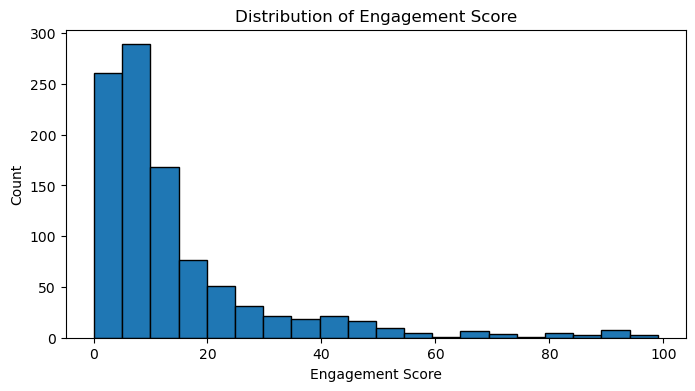

In [164]:
plt.figure(figsize=(8, 4))
plt.hist(df_encode['engagement_score'], bins=20, edgecolor='black')
plt.title('Distribution of Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Count')
plt.show()

In [166]:
income_median = df_encode['income'].median()

df_encode['high_value'] = ( (df_encode['subscription_type_Premium'] == 1) & (df_encode['income'] > income_median).astype(int) )

In [167]:
# Combine risk factors
df_encode['risk_score'] = (
    (df_encode['contract_length_Quarterly'] == 1) * 2 +
    (df_encode['has_loyalty_card'] == 0) * 3 +
    (df_encode['customer_service_calls'] > 5) * 2
)

In [168]:
df_encode['usage_per_age'] = df_encode['monthly_usage_hours'] / (df_encode['age'] + 1)

In [169]:
df_encode['low_engagement'] = (df_encode['monthly_usage_hours'] < 30).astype(int)

In [171]:
correlations = df_encode.corr()['churned'].sort_values(ascending=False)
print("Feature correlations with churned:")
print(correlations)

Feature correlations with churned:
churned                       1.000000
usage_per_age                 0.101713
monthly_usage_hours           0.059793
engagement_score              0.038125
payment_method_PayPal         0.026656
has_loyalty_card              0.024650
region_North                  0.014633
is_male                       0.012513
subscription_type_Standard    0.008880
customer_id                   0.007067
customer_service_calls        0.006525
subscription_type_Premium     0.005529
contract_length_Yearly        0.001620
high_value                   -0.003667
region_West                  -0.015581
risk_score                   -0.026271
region_South                 -0.029379
low_engagement               -0.036068
age                          -0.038304
payment_method_Cash          -0.041661
contract_length_Quarterly    -0.042824
payment_method_Credit Card   -0.043485
income                       -0.050152
Name: churned, dtype: float64


In [172]:
# Drop customer_id (not useful)
df_encode = df_encode.drop('customer_id', axis=1)

# Drop any features with very low correlation (optional)
# For example, drop features with |correlation| < 0.01

In [176]:
from sklearn.model_selection import train_test_split

# Define X and y FIRST
X = df_encode.drop('churned', axis=1)
y = df_encode['churned']

# THEN split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (800, 21)
X_test: (200, 21)
y_train: (800,)
y_test: (200,)


In [175]:
# Save the engineered dataset
df_encode.to_csv('customer_churn_engineered.csv', index=False)
print("Engineered dataset saved!")

Engineered dataset saved!
